# Data Breach Analysis

A comprehensive analysis of data breaches across industries, companies, and time periods (2000-2024).

**Dataset:** 12,378 breach records with information on breach type, financial loss, records compromised, human error factors, and mitigation measures.

## 1. Setup & Data Loading

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../dataset/raw/DataBreach_dataset.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head(10)

Dataset loaded: 12378 rows, 10 columns


,Year,Company Name,Type of Breach,Records Compromised,Financial Loss,Impact Level,Industry,Human Error Factor,Human Error Factor Code,Mitigation Measures
0,2003,HP,Insider Threat,684226,436185.207,Medium,Technology,Unintentional Info Leak,1,Access Controls
1,2018,Facebook,Physical Breach,289946,1036712.876,Medium,Technology,Improper Disposal,2,Access Controls
2,2017,Target,Insider Threat,188401,2469034.317,High,Retail,Weak Password Management,5,Data Encryption
3,2018,Home Depot,DDoS Attack,740764,2045959.209,Medium,Retail,Phishing Attack,4,Regular Security Training
4,2014,DOD,Phishing,225875,2003786.087,High,Government,Phishing Attack,4,Regular Audits
5,2022,Best Buy,Malware,409004,1436217.513,Low,Retail,Insider Threat,3,Regular Security Training
6,2015,UPMC,Insider Threat,93422,1546994.971,Medium,Healthcare,Insider Threat,3,Regular Audits
7,2001,Tenet Healthcare,Insider Threat,644789,2454352.793,Medium,Healthcare,Weak Password Management,5,Two-factor Authentication
8,2024,Home Depot,Password Guessing,519382,2551026.717,Medium,Retail,Weak Password Management,5,Data Encryption
9,2006,Treasury Department,DDoS Attack,629636,1511230.999,High,Government,Insider Threat,3,Regular Security Training


## 2. Data Inspection

In [18]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12378 entries, 0 to 12377
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     12378 non-null  int64  
 1   Company Name             12378 non-null  object 
 2   Type of Breach           12378 non-null  object 
 3   Records Compromised      12378 non-null  int64  
 4   Financial Loss           12378 non-null  float64
 5   Impact Level             12378 non-null  object 
 6   Industry                 12378 non-null  object 
 7   Human Error Factor       12378 non-null  object 
 8   Human Error Factor Code  12378 non-null  int64  
 9   Mitigation Measures      12378 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 967.2+ KB


In [19]:
# Statistical summary for numeric columns
df.describe()

,Year,Records Compromised,Financial Loss,Human Error Factor Code
count,12378.000000,12378.000000,1.237800e+04,12378.000000
mean,2012.037405,499134.714817,1.505621e+06,3.020197
std,7.167305,288876.950354,7.006259e+05,1.412411
min,2000.000000,1073.000000,3.394024e+05,1.000000
25%,2006.000000,246897.000000,9.672864e+05,2.000000
50%,2012.000000,499742.500000,1.500717e+06,3.000000
75%,2018.000000,746188.250000,2.038622e+06,4.000000
max,2024.000000,999978.000000,2.664563e+06,5.000000


In [20]:
# Statistical summary for categorical columns
df.describe(include='object')

,Company Name,Type of Breach,Impact Level,Industry,Human Error Factor,Mitigation Measures
count,12378,12378,12378,12378,12378,12378
unique,49,7,4,5,5,5
top,Amazon,Password Guessing,High,Finance,Weak Password Management,Regular Security Training
freq,434,1800,4628,2530,2537,2529


In [21]:
# Check for missing values and duplicates
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
Year                       0
Company Name               0
Type of Breach             0
Records Compromised        0
Financial Loss             0
Impact Level               0
Industry                   0
Human Error Factor         0
Human Error Factor Code    0
Mitigation Measures        0
dtype: int64

Duplicate rows: 0


In [22]:
# Unique values per column
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

Year: 25 unique values
Company Name: 49 unique values
Type of Breach: 7 unique values
Records Compromised: 12307 unique values
Financial Loss: 12378 unique values
Impact Level: 4 unique values
Industry: 5 unique values
Human Error Factor: 5 unique values
Human Error Factor Code: 5 unique values
Mitigation Measures: 5 unique values


## 3. Data Cleaning & Preprocessing

In [23]:
# Strip whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()

print('Human Error Factors after cleaning:', df['Human Error Factor'].unique())
print('\nImpact Level values:', df['Impact Level'].unique())

Human Error Factors after cleaning: ['Unintentional Info Leak' 'Improper Disposal' 'Weak Password Management'
 'Phishing Attack' 'Insider Threat']

Impact Level values: ['Medium' 'High' 'Low' 'Critical']


In [24]:
# Create ordered category for Impact Level
impact_order = ['Low', 'Medium', 'High', 'Critical']
df['Impact Level'] = pd.Categorical(df['Impact Level'], categories=impact_order, ordered=True)

# Financial loss category
df['Loss Category'] = pd.cut(df['Financial Loss'],
                              bins=[0, 500000, 1000000, 1500000, 2000000, float('inf')],
                              labels=['<500K', '500K-1M', '1M-1.5M', '1.5M-2M', '>2M'])

# Records compromised category
df['Records Category'] = pd.cut(df['Records Compromised'],
                                 bins=[0, 200000, 400000, 600000, 800000, float('inf')],
                                 labels=['<200K', '200K-400K', '400K-600K', '600K-800K', '>800K'])

print('New columns added: Loss Category, Records Category')
print(f'\nLoss Category distribution:\n{df["Loss Category"].value_counts().sort_index()}')
print(f'\nRecords Category distribution:\n{df["Records Category"].value_counts().sort_index()}')

New columns added: Loss Category, Records Category

Loss Category distribution:
Loss Category
<500K      1123
500K-1M    2479
1M-1.5M    2573
1.5M-2M    2504
>2M        3699
Name: count, dtype: int64

Records Category distribution:
Records Category
<200K        2478
200K-400K    2443
400K-600K    2492
600K-800K    2504
>800K        2461
Name: count, dtype: int64


In [25]:
# Save cleaned data
df.to_csv('../dataset/cleaned/data_breaches_cleaned.csv', index=False)
print('Cleaned dataset saved to dataset/cleaned/data_breaches_cleaned.csv')

Cleaned dataset saved to dataset/cleaned/data_breaches_cleaned.csv


## 4. Breach Type Analysis

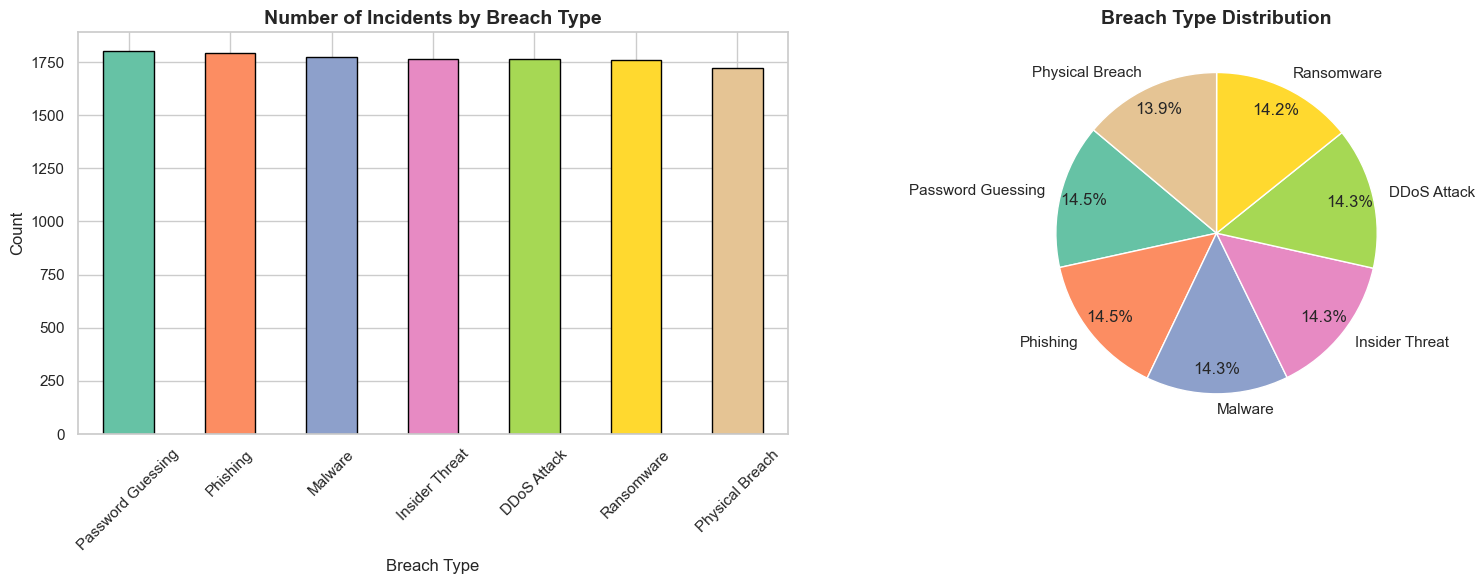

In [26]:
# Breach type frequency
breach_counts = df['Type of Breach'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('Set2', len(breach_counts))
breach_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Number of Incidents by Breach Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Breach Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(breach_counts.values, labels=breach_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.85)
axes[1].set_title('Breach Type Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
# Average financial loss and records compromised by breach type
breach_impact = df.groupby('Type of Breach').agg(
    avg_loss=('Financial Loss', 'mean'),
    avg_records=('Records Compromised', 'mean'),
    total_loss=('Financial Loss', 'sum'),
    total_records=('Records Compromised', 'sum'),
    count=('Year', 'count')
).sort_values('avg_loss', ascending=False)

breach_impact['avg_loss'] = breach_impact['avg_loss'].round(2)
breach_impact['avg_records'] = breach_impact['avg_records'].round(0).astype(int)
breach_impact['total_loss'] = breach_impact['total_loss'].round(2)

print('Breach Type Impact Summary:')
breach_impact

Breach Type Impact Summary:


,avg_loss,avg_records,total_loss,total_records,count
Type of Breach,,,,,
Phishing,1529278.17,500106,2.738937e+09,895690247,1791
Malware,1513020.76,502962,2.685612e+09,892757404,1775
Insider Threat,1511218.75,494276,2.667301e+09,872396681,1765
Password Guessing,1506166.33,513601,2.711099e+09,924481032,1800
Ransomware,1504890.22,488383,2.651617e+09,860531368,1762
Physical Breach,1493072.08,492702,2.568084e+09,847447144,1720
DDoS Attack,1480977.01,501408,2.613924e+09,884985624,1765


In [28]:
# Financial loss distribution by breach type (interactive)
fig = px.box(df, x='Type of Breach', y='Financial Loss', color='Type of Breach',
             title='Financial Loss Distribution by Breach Type',
             labels={'Financial Loss': 'Financial Loss ($)', 'Type of Breach': 'Breach Type'})
fig.update_layout(showlegend=False, xaxis_tickangle=-45)
fig.show()

## 5. Industry Analysis

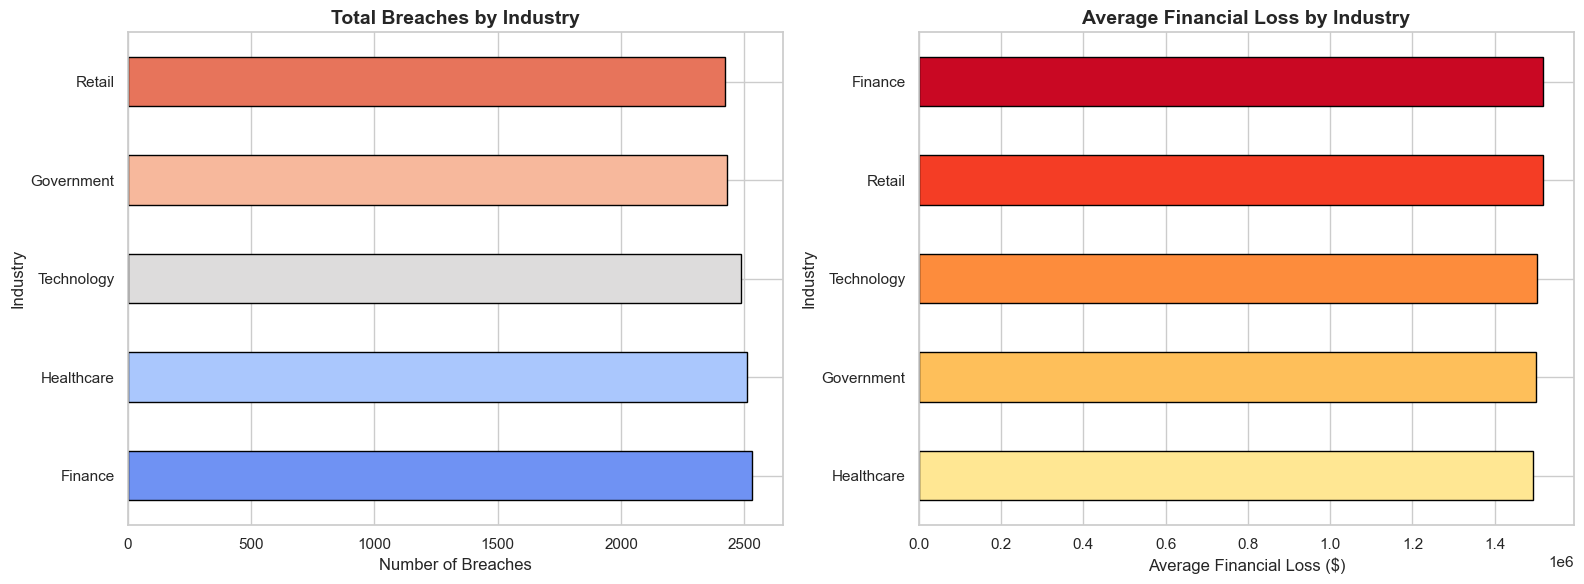

In [29]:
# Breaches per industry
industry_counts = df['Industry'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_ind = sns.color_palette('coolwarm', len(industry_counts))
industry_counts.plot(kind='barh', ax=axes[0], color=colors_ind, edgecolor='black')
axes[0].set_title('Total Breaches by Industry', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Breaches')

industry_loss = df.groupby('Industry')['Financial Loss'].mean().sort_values(ascending=True)
industry_loss.plot(kind='barh', ax=axes[1], color=sns.color_palette('YlOrRd', len(industry_loss)), edgecolor='black')
axes[1].set_title('Average Financial Loss by Industry', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Financial Loss ($)')

plt.tight_layout()
plt.show()

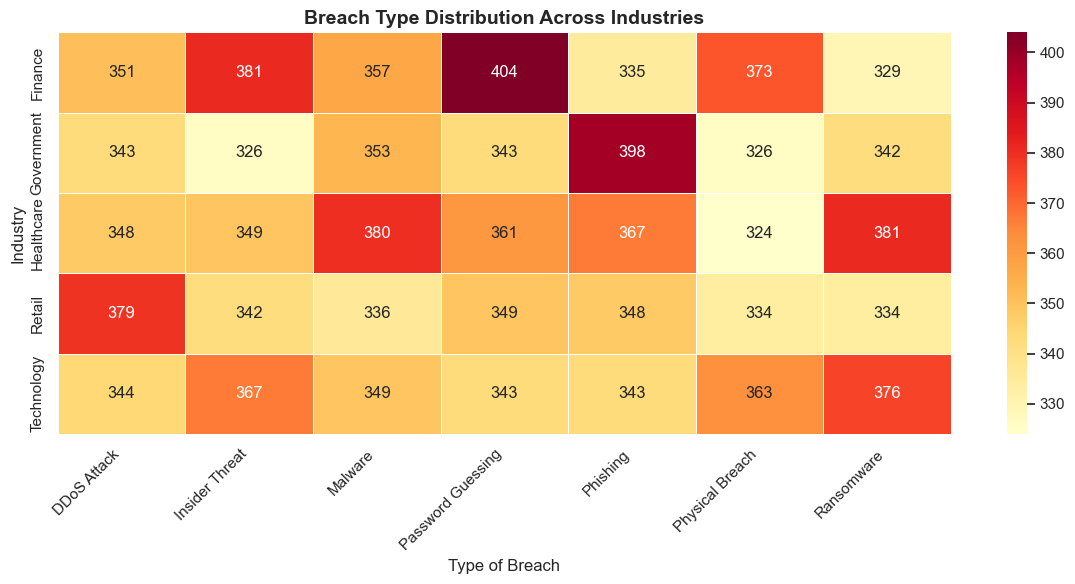

In [30]:
# Breach types across industries - heatmap
cross_tab = pd.crosstab(df['Industry'], df['Type of Breach'])

plt.figure(figsize=(12, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Breach Type Distribution Across Industries', fontsize=14, fontweight='bold')
plt.xlabel('Type of Breach')
plt.ylabel('Industry')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
# Impact level distribution across industries
impact_cross = pd.crosstab(df['Industry'], df['Impact Level'])

fig = px.bar(impact_cross, barmode='group',
             title='Impact Level Distribution Across Industries',
             labels={'value': 'Count', 'Industry': 'Industry'})
fig.update_layout(xaxis_tickangle=-45, legend_title='Impact Level')
fig.show()

In [32]:
# Industry summary table
industry_summary = df.groupby('Industry').agg(
    total_records=('Records Compromised', 'sum'),
    total_loss=('Financial Loss', 'sum'),
    avg_records=('Records Compromised', 'mean'),
    avg_loss=('Financial Loss', 'mean'),
    breach_count=('Year', 'count')
).round(2).sort_values('total_loss', ascending=False)

print('Industry Summary:')
industry_summary

Industry Summary:


,total_records,total_loss,avg_records,avg_loss,breach_count
Industry,,,,,
Finance,1272990681,3.837635e+09,503158.37,1516851.77,2530
Healthcare,1223931338,3.746680e+09,487622.05,1492701.02,2510
Technology,1257383192,3.732763e+09,505989.21,1502117.92,2485
Retail,1204461168,3.672751e+09,497300.23,1516412.62,2422
Government,1219523121,3.646746e+09,501654.92,1500101.01,2431


## 6. Temporal / Trend Analysis

In [33]:
# Breaches per year
yearly_counts = df.groupby('Year').size().reset_index(name='Count')

fig = px.line(yearly_counts, x='Year', y='Count', markers=True,
              title='Number of Data Breaches Over Time (2000-2024)',
              labels={'Count': 'Number of Breaches'})
fig.update_traces(line=dict(width=3))
fig.update_layout(xaxis=dict(dtick=1))
fig.show()

In [37]:
# Yearly financial loss and records trend
yearly_loss = df.groupby('Year').agg(
    total_loss=('Financial Loss', 'sum'),
    avg_loss=('Financial Loss', 'mean'),
    total_records=('Records Compromised', 'sum')
).reset_index()

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=('Total Financial Loss by Year', 'Total Records Compromised by Year'))

fig.add_trace(go.Bar(x=yearly_loss['Year'], y=yearly_loss['total_loss'],
                     name='Total Loss ($)', marker_color='indianred'), row=1, col=1)
fig.add_trace(go.Bar(x=yearly_loss['Year'], y=yearly_loss['total_records'],
                     name='Total Records', marker_color='steelblue'), row=2, col=1)

fig.update_layout(height=700, title_text='Financial Loss & Records Compromised Over Time', showlegend=True)
fig.show()

In [36]:
# Breach type trends over time
breach_yearly = df.groupby(['Year', 'Type of Breach']).size().reset_index(name='Count')

fig = px.area(breach_yearly, x='Year', y='Count', color='Type of Breach',
              title='Breach Type Trends Over Time',
              labels={'Count': 'Number of Breaches'})
fig.update_layout(xaxis=dict(dtick=2))
fig.show()

In [38]:
# Industry breach trends over time
industry_yearly = df.groupby(['Year', 'Industry']).size().reset_index(name='Count')

fig = px.line(industry_yearly, x='Year', y='Count', color='Industry', markers=True,
              title='Breach Trends by Industry Over Time',
              labels={'Count': 'Number of Breaches'})
fig.update_layout(xaxis=dict(dtick=2))
fig.show()

## 7. Human Error Factor Analysis

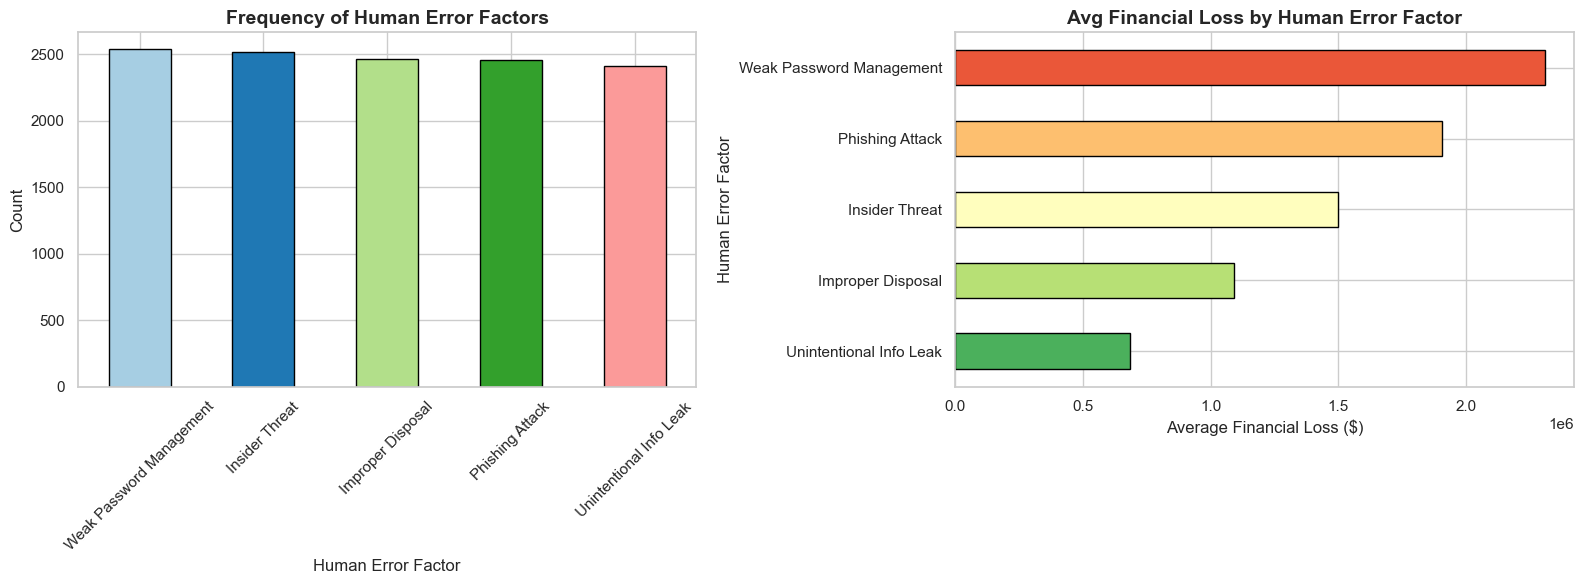

In [39]:
# Human error factor frequency and financial impact
error_counts = df['Human Error Factor'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_err = sns.color_palette('Paired', len(error_counts))
error_counts.plot(kind='bar', ax=axes[0], color=colors_err, edgecolor='black')
axes[0].set_title('Frequency of Human Error Factors', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Human Error Factor')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

error_loss = df.groupby('Human Error Factor')['Financial Loss'].mean().sort_values(ascending=True)
error_loss.plot(kind='barh', ax=axes[1], color=sns.color_palette('RdYlGn_r', len(error_loss)), edgecolor='black')
axes[1].set_title('Avg Financial Loss by Human Error Factor', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Financial Loss ($)')

plt.tight_layout()
plt.show()

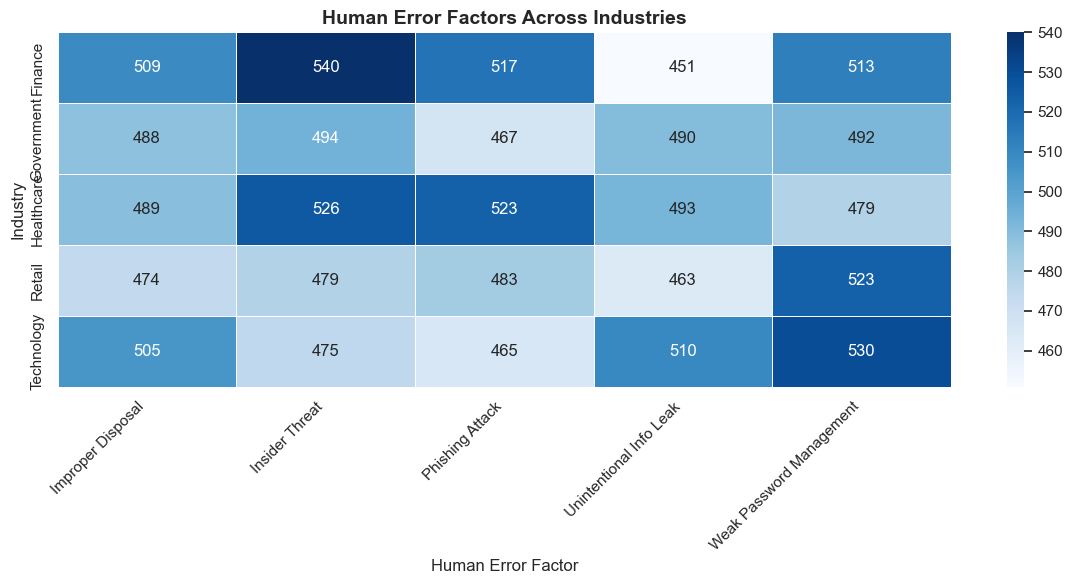

In [41]:
# Human error by industry - heatmap
error_industry = pd.crosstab(df['Industry'], df['Human Error Factor'])

plt.figure(figsize=(12, 6))
sns.heatmap(error_industry, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Human Error Factors Across Industries', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Financial Impact & Records Compromised Analysis

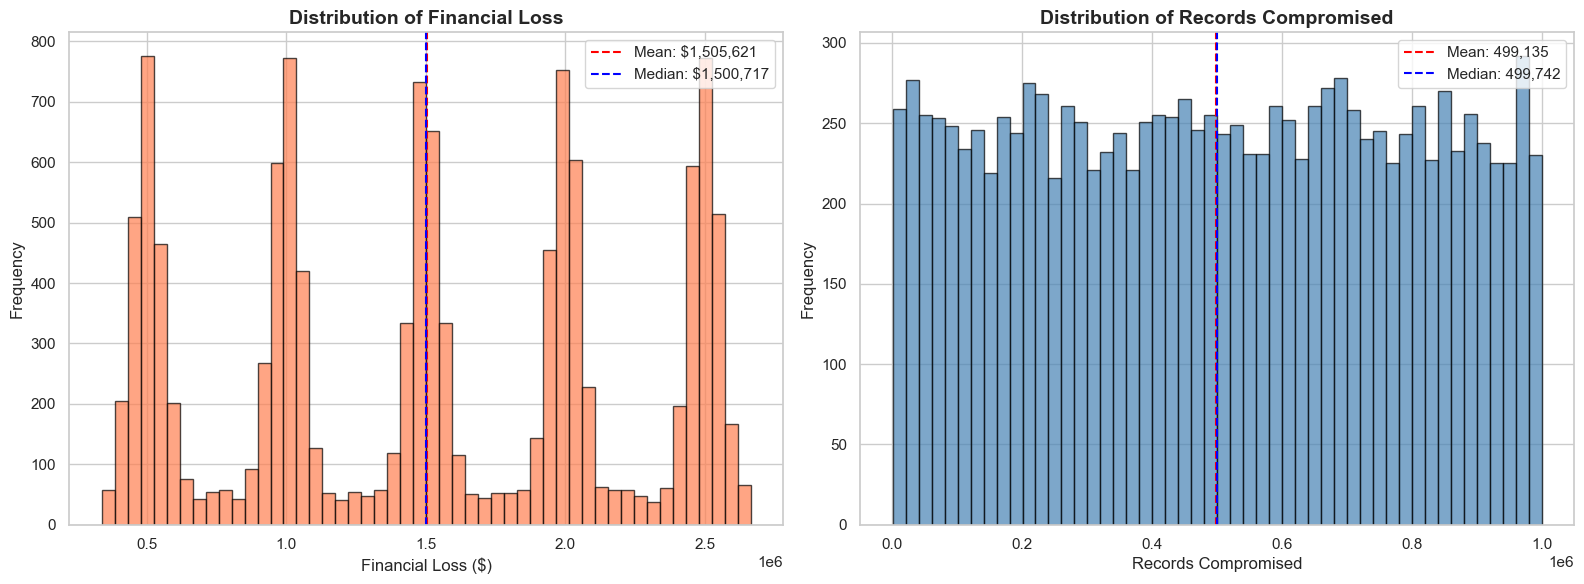

In [42]:
# Distribution of financial loss and records compromised
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['Financial Loss'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Financial Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Financial Loss ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Financial Loss'].mean(), color='red', linestyle='--',
                label=f"Mean: ${df['Financial Loss'].mean():,.0f}")
axes[0].axvline(df['Financial Loss'].median(), color='blue', linestyle='--',
                label=f"Median: ${df['Financial Loss'].median():,.0f}")
axes[0].legend()

axes[1].hist(df['Records Compromised'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Records Compromised', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Records Compromised')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['Records Compromised'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['Records Compromised'].mean():,.0f}")
axes[1].axvline(df['Records Compromised'].median(), color='blue', linestyle='--',
                label=f"Median: {df['Records Compromised'].median():,.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [43]:
# Scatter: Records compromised vs Financial loss (interactive)
fig = px.scatter(df, x='Records Compromised', y='Financial Loss', color='Industry',
                 size='Records Compromised', hover_data=['Company Name', 'Type of Breach', 'Year'],
                 title='Records Compromised vs Financial Loss',
                 labels={'Financial Loss': 'Financial Loss ($)', 'Records Compromised': 'Records Compromised'},
                 opacity=0.6)
fig.show()

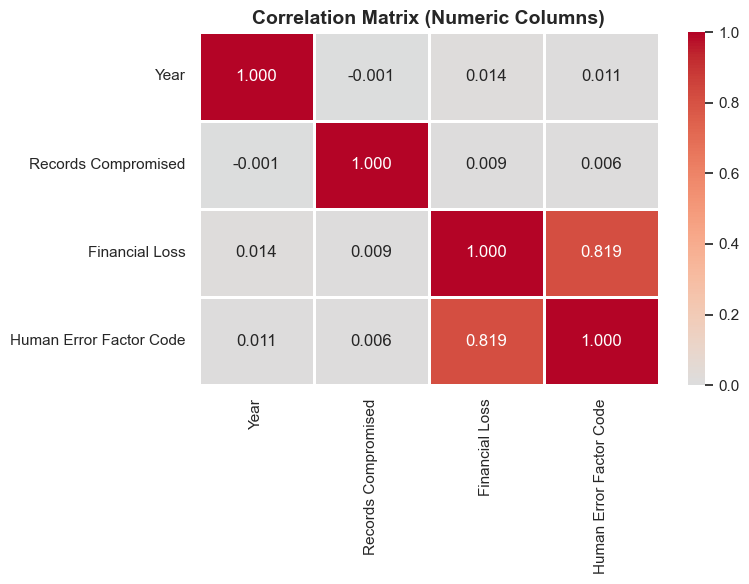

In [45]:
# Correlation matrix
numeric_cols = df.select_dtypes(include=[np.number])
correlation = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.3f', linewidths=1)
plt.title('Correlation Matrix (Numeric Columns)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Company-Level Analysis

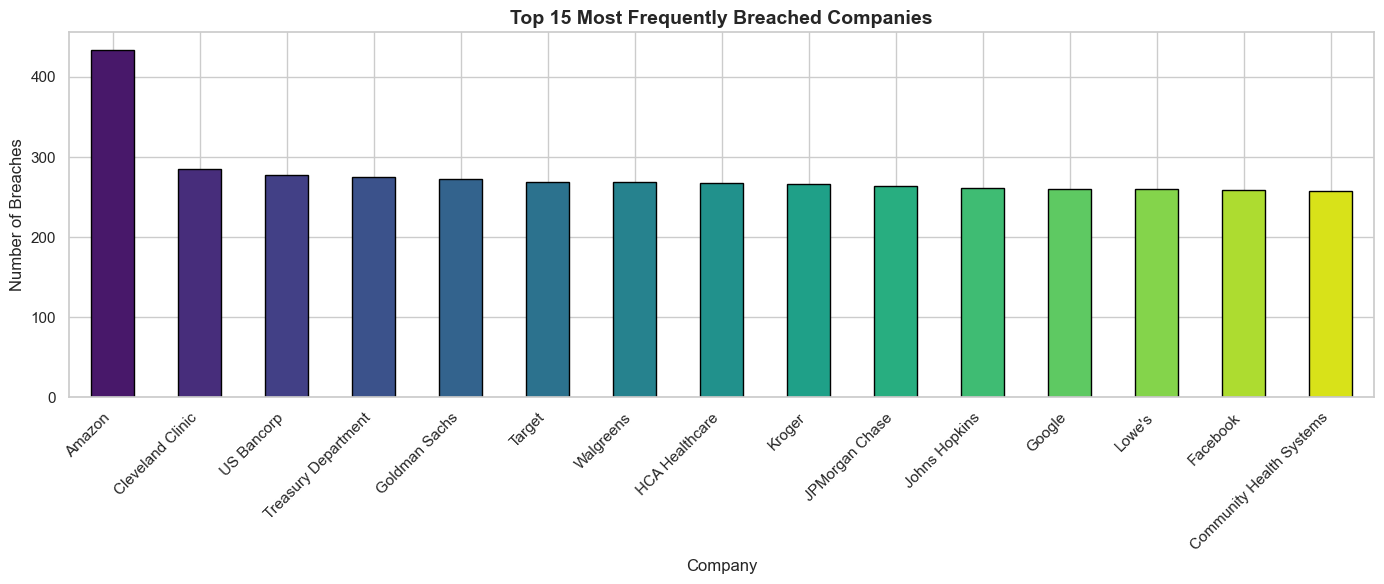

In [46]:
# Top 15 most breached companies
top_companies = df['Company Name'].value_counts().head(15)

plt.figure(figsize=(14, 6))
colors_comp = sns.color_palette('viridis', len(top_companies))
top_companies.plot(kind='bar', color=colors_comp, edgecolor='black')
plt.title('Top 15 Most Frequently Breached Companies', fontsize=14, fontweight='bold')
plt.xlabel('Company')
plt.ylabel('Number of Breaches')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [47]:
# Top 15 companies by total financial loss (interactive)
company_loss = df.groupby('Company Name').agg(
    total_loss=('Financial Loss', 'sum'),
    avg_loss=('Financial Loss', 'mean'),
    total_records=('Records Compromised', 'sum'),
    breach_count=('Year', 'count')
).sort_values('total_loss', ascending=False).head(15)

fig = px.bar(company_loss.reset_index(), x='Company Name', y='total_loss',
             color='breach_count', color_continuous_scale='Reds',
             hover_data=['avg_loss', 'total_records', 'breach_count'],
             title='Top 15 Companies by Total Financial Loss',
             labels={'total_loss': 'Total Financial Loss ($)', 'breach_count': 'Breach Count'})
fig.update_layout(xaxis_tickangle=-45)
fig.show()

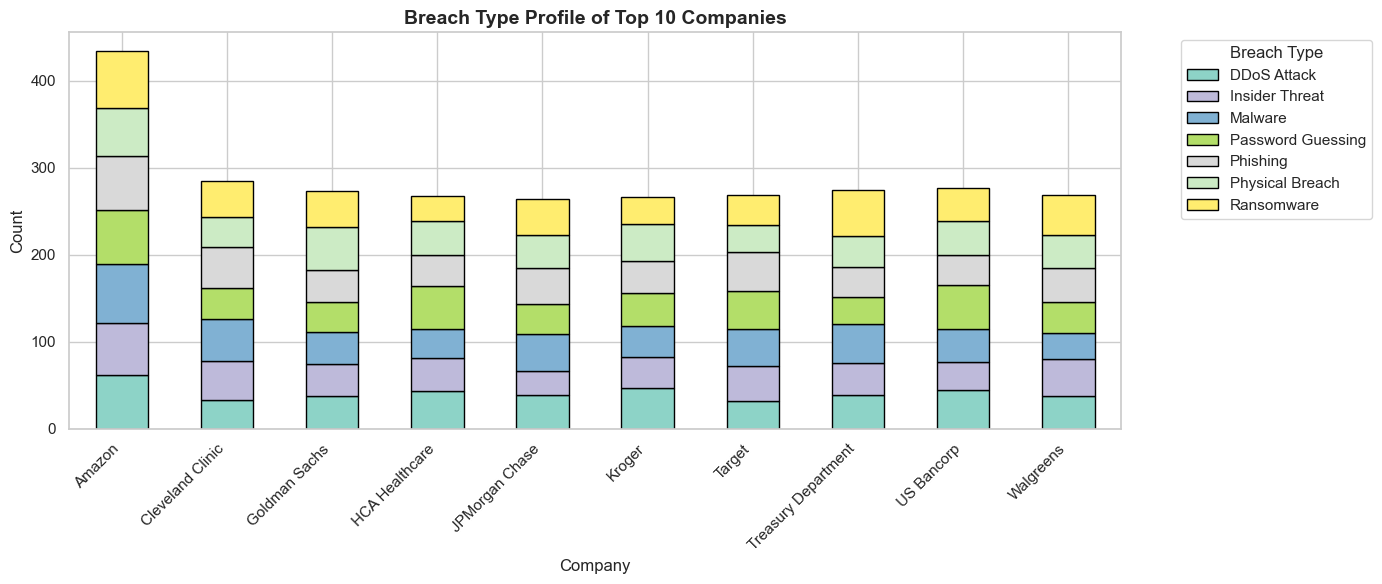

In [48]:
# Breach type profile for top 10 companies
top10 = df['Company Name'].value_counts().head(10).index
company_breach = pd.crosstab(df[df['Company Name'].isin(top10)]['Company Name'],
                              df[df['Company Name'].isin(top10)]['Type of Breach'])

company_breach.plot(kind='bar', stacked=True, colormap='Set3', edgecolor='black', figsize=(14, 6))
plt.title('Breach Type Profile of Top 10 Companies', fontsize=14, fontweight='bold')
plt.xlabel('Company')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Breach Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. Mitigation Measures Analysis

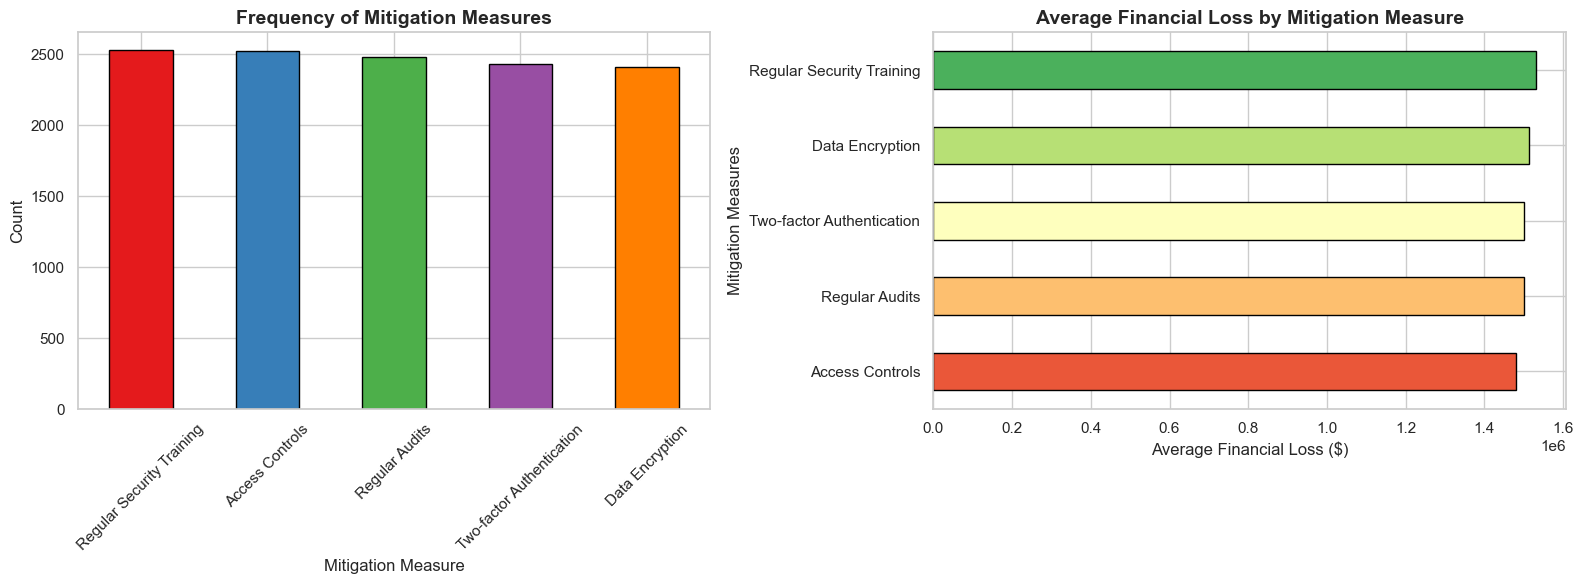

In [49]:
# Mitigation measure frequency and average loss
mitigation_counts = df['Mitigation Measures'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_mit = sns.color_palette('Set1', len(mitigation_counts))
mitigation_counts.plot(kind='bar', ax=axes[0], color=colors_mit, edgecolor='black')
axes[0].set_title('Frequency of Mitigation Measures', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mitigation Measure')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

mit_loss = df.groupby('Mitigation Measures')['Financial Loss'].mean().sort_values(ascending=True)
mit_loss.plot(kind='barh', ax=axes[1], color=sns.color_palette('RdYlGn', len(mit_loss)), edgecolor='black')
axes[1].set_title('Average Financial Loss by Mitigation Measure', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Financial Loss ($)')

plt.tight_layout()
plt.show()

## 11. Key Insights & Summary

In [52]:
# Comprehensive summary
print('=' * 70)
print('KEY FINDINGS - DATA BREACH ANALYSIS (2000-2024)')
print('=' * 70)

print(f'''
DATASET OVERVIEW:
  Total breach records: {len(df):,}
  Time period: {df['Year'].min()} - {df['Year'].max()}
  Companies covered: {df['Company Name'].nunique()}
  Industries: {df['Industry'].nunique()} ({', '.join(df['Industry'].unique())})

FINANCIAL IMPACT:
  Total financial loss: ${df['Financial Loss'].sum():,.2f}
  Average loss per breach: ${df['Financial Loss'].mean():,.2f}
  Median loss per breach: ${df['Financial Loss'].median():,.2f}
  Max single breach loss: ${df['Financial Loss'].max():,.2f}

RECORDS COMPROMISED:
  Total records compromised: {df['Records Compromised'].sum():,}
  Average per breach: {df['Records Compromised'].mean():,.0f}
  Max single breach: {df['Records Compromised'].max():,}

MOST COMMON:
  Breach type: {df['Type of Breach'].value_counts().index[0]} ({df['Type of Breach'].value_counts().iloc[0]:,} incidents)
  Industry: {df['Industry'].value_counts().index[0]} ({df['Industry'].value_counts().iloc[0]:,} incidents)
  Human error: {df['Human Error Factor'].value_counts().index[0]} ({df['Human Error Factor'].value_counts().iloc[0]:,} incidents)
  Mitigation: {df['Mitigation Measures'].value_counts().index[0]} ({df['Mitigation Measures'].value_counts().iloc[0]:,} incidents)

MOST COSTLY:
  Industry (avg loss): {df.groupby('Industry')['Financial Loss'].mean().idxmax()} (${df.groupby('Industry')['Financial Loss'].mean().max():,.2f})
  Breach type (avg loss): {df.groupby('Type of Breach')['Financial Loss'].mean().idxmax()} (${df.groupby('Type of Breach')['Financial Loss'].mean().max():,.2f})
  Company (total loss): {df.groupby('Company Name')['Financial Loss'].sum().idxmax()} (${df.groupby('Company Name')['Financial Loss'].sum().max():,.2f})

MOST TARGETED COMPANY:
  {df['Company Name'].value_counts().index[0]} with {df['Company Name'].value_counts().iloc[0]:,} breaches
''')
print('=' * 70)

KEY FINDINGS - DATA BREACH ANALYSIS (2000-2024)

DATASET OVERVIEW:
  Total breach records: 12,378
  Time period: 2000 - 2024
  Companies covered: 49
  Industries: 5 (Technology, Retail, Government, Healthcare, Finance)

FINANCIAL IMPACT:
  Total financial loss: $18,636,574,500.98
  Average loss per breach: $1,505,620.82
  Median loss per breach: $1,500,716.63
  Max single breach loss: $2,664,563.03

RECORDS COMPROMISED:
  Total records compromised: 6,178,289,500
  Average per breach: 499,135
  Max single breach: 999,978

MOST COMMON:
  Breach type: Password Guessing (1,800 incidents)
  Industry: Finance (2,530 incidents)
  Human error: Weak Password Management (2,537 incidents)
  Mitigation: Regular Security Training (2,529 incidents)

MOST COSTLY:
  Industry (avg loss): Finance ($1,516,851.77)
  Breach type (avg loss): Phishing ($1,529,278.17)
  Company (total loss): Amazon ($641,700,245.61)

MOST TARGETED COMPANY:
  Amazon with 434 breaches

